# Foundation Model Embedding + Fusion Classifier Comparison

This notebook merges two pieces of work:

1. **Embedding pipeline** (adapted from Arda's general embedding-framework script) — runs the
   in-house fused / parental / resistant cells through the pretrained `sc_embedd` model to get a
   low-dimensional latent representation.
2. **Classifier pipeline** (adapted from my script `Fusion_signature_Oct2025.ipynb`) — trains RF and RF+LDA
   classifiers to predict sample identity (fused / parental / resistant).

Workflow: preprocess in-house data → embed with `sc_embedd` → train/test RF and RF+LDA classifiers
on the **embedding** → compare against the classifiers trained on raw HVG expression (original
notebook results reproduced here for a side-by-side comparison).

## 0. Assumptions status

- **Gene panel — resolved.** `MODEL_FEAT_PATH` should point at the real feature file found on the
  cluster; Section 2 reindexes the in-house data to match it exactly. When last run, the feature
  count matched the model's expected input width (1548) exactly — treat this as trustworthy since
  it's sourced from the model's own metadata, not a guess.
- **Batch covariate — open, stopgap in place.** `sc_embedd` expects a 19-wide batch one-hot
  (confirmed from a shape-mismatch error), not `sample` (fused/parental/resistant, 3-wide). Those
  19 categories are training batches our in-house cells were never part of, so there's no correct
  per-cell mapping onto them. Section 3 assigns every cell a single fixed reference category as a
  stopgap; Section 4 includes a diagnostic that checks whether the embedding output is even
  sensitive to that choice before you trust downstream results.
- **Preprocessing state**: we feed the model normalized + log1p-transformed counts on the full
  gene panel (not the HVG-subset/scaled/regressed matrix used for the RF classifiers). Not
  independently verified against how the model was trained, but consistent with the original
  script's apparent preprocessing convention.

## Imports

In [16]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf

# classifier pieces (same as Fusion_signature_Oct2025.ipynb)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report,
    roc_curve, roc_auc_score,
)

from sklearn.manifold import TSNE
import seaborn as sns

## Paths

`wd` is the cluster location for the pretrained model (from Arda's script, now pointed at your
storage). Adjust `MODEL_FEAT_PATH` if the model ships with an explicit gene-panel file — otherwise
leave it `None` and gene alignment will be skipped (see assumptions above).

In [17]:
wd = '/mnt/vstor/SOM_CCCC_JGS25/durmaza/'

MODEL_DIR = f'{wd}/sc_embedd_model/1/'
MODEL_FEAT_PATH = f'{wd}/lung_ext_feat.tsv.gz'  # e.g. f'{wd}/sc_embedd_feat.tsv.gz' — set this if the model ships a fixed gene panel

results_file = 'combined_analyzed_Oct2025.h5ad'  # written by Fusion_signature_Oct2025.ipynb

## 1. Load In-House Data

Reuses the fused / parental / resistant loading + QC from `Fusion_signature_Oct2025.ipynb`. Raw
filtered counts are shared (QC thresholds are identical either way), but normalization then splits
into two **independent** branches: `adata_embed_input` (whatever preprocessing `sc_embedd` needs)
and `adata_combined_filtered` (frozen to the exact original notebook's preprocessing, for a
faithful Section 8 baseline). See the next cell for why they're kept separate rather than shared.

In [18]:
adata_fus = sc.read_10x_mtx('../fused/', var_names='gene_symbols', cache=True)
adata_fus.obs['sample'] = 'fused'
adata_fus.obs.index = [f'F_{bc}' for bc in adata_fus.obs.index]

adata_par = sc.read_10x_mtx('../parental/', var_names='gene_symbols', cache=True)
adata_par.obs['sample'] = 'parental'
adata_par.obs.index = [f'P_{bc}' for bc in adata_par.obs.index]

adata_res = sc.read_10x_mtx('../resistant/', var_names='gene_symbols', cache=True)
adata_res.obs['sample'] = 'resistant'
adata_res.obs.index = [f'R_{bc}' for bc in adata_res.obs.index]

for a in (adata_fus, adata_par, adata_res):
    a.var_names_make_unique()

adata_combined = ad.concat([adata_fus, adata_par, adata_res])

In [ ]:
# QC + filtering (mirrors Fusion_signature_Oct2025.ipynb)
adata_combined.var['mt'] = adata_combined.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata_combined, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

sc.pp.filter_cells(adata_combined, min_genes=200)
sc.pp.filter_genes(adata_combined, min_cells=3)

adata_combined_filtered = adata_combined[adata_combined.obs.total_counts < 75000, :]
adata_combined_filtered = adata_combined_filtered[adata_combined_filtered.obs.n_genes > 1000, :]
adata_combined_filtered = adata_combined_filtered[adata_combined_filtered.obs.pct_counts_mt < 40, :]
adata_combined_filtered = adata_combined_filtered.copy()

# Raw filtered counts only -- normalization is applied per-branch in the next cell so the
# embedding preprocessing and the classifier-reproduction preprocessing can never again silently
# share (and corrupt) each other. See that cell for why this matters.

In [ ]:
# Embedding-model branch: full gene panel, whatever normalization sc_embedd expects (currently
# exclude_highly_expressed=True, target_sum=1e8, asinh transform -- carried over from cluster-side
# tuning). Kept independent of the classifier-reproduction branch below so changes here can never
# again silently corrupt the "reproduce the original classifiers" baseline in Section 8 -- that's
# what caused HVG RF/RF+LDA accuracy to collapse to ~0.47 (from 0.917/0.951 in the original
# notebook) when both branches shared one normalize_total call.
def asinh(x):
    return np.log(x + np.sqrt(x**2.0 + 1.0))

adata_embed_input = adata_combined_filtered.copy()
sc.pp.normalize_total(adata_embed_input, exclude_highly_expressed=True, target_sum=1e8)
adata_embed_input.X = asinh(adata_embed_input.X.toarray())

# Original-classifier-reproduction branch: rebuilt independently from the raw filtered counts
# using the EXACT preprocessing from Fusion_signature_Oct2025.ipynb (target_sum=1e6, plain
# log1p, no exclude_highly_expressed), so Section 8 stays a faithful, fixed baseline regardless
# of what preprocessing the embedding branch above evolves to.
adata_combined_filtered = adata_combined_filtered.copy()
sc.pp.normalize_total(adata_combined_filtered, target_sum=1e6)
sc.pp.log1p(adata_combined_filtered)
sc.pp.highly_variable_genes(adata_combined_filtered, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata_combined_filtered = adata_combined_filtered[:, adata_combined_filtered.var.highly_variable].copy()
sc.pp.regress_out(adata_combined_filtered, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata_combined_filtered, max_value=10)
adata_combined_filtered.write_h5ad(results_file)

## 2. Align Genes to the Model's Expected Panel

Skipped (with a warning) if `MODEL_FEAT_PATH` is `None`.

In [25]:
if MODEL_FEAT_PATH is not None:
    model_feat = pd.read_csv(MODEL_FEAT_PATH, sep='\t')
    model_genes = model_feat.iloc[:, 0].astype(str).tolist()

    n_matched = adata_embed_input.var_names.isin(model_genes).sum()
    print(f'{n_matched}/{len(model_genes)} model genes found in in-house panel')

    adata_embed_input = adata_embed_input[:, [g for g in model_genes if g in adata_embed_input.var_names]]
    # reindex to the model's exact gene order, filling any still-missing genes with 0
    missing = [g for g in model_genes if g not in adata_embed_input.var_names]
    if missing:
        print(f'Filling {len(missing)} genes absent from in-house data with 0 expression')
        pad = ad.AnnData(
            X=np.zeros((adata_embed_input.n_obs, len(missing)), dtype=np.float32),
            obs=adata_embed_input.obs,
            var=pd.DataFrame(index=missing),
        )
        adata_embed_input = ad.concat([adata_embed_input, pad], axis=1)
    adata_embed_input = adata_embed_input[:, model_genes].copy()
else:
    print('MODEL_FEAT_PATH not set — using in-house gene panel as-is. '
          'Verify this matches what sc_embedd expects before trusting the embedding.')

1548/1548 model genes found in in-house panel


## 3. Batch Covariate

**Diagnosed from a shape-mismatch error**: `sc_embedd` expects a **19-wide** one-hot batch
covariate (`input_2` shape `(None, 19)`), not the 3-wide `sample` (fused/parental/resistant)
encoding used before. Those 19 categories are almost certainly the *training* batches (e.g. from
the lung_ext data), which our in-house cells were never assigned to — there's no principled
per-cell mapping from "fused"/"parental"/"resistant" into that set.

Two things, in order:

1. **Look for the original training `obs` file**, in the same place you found the feat file
   (likely named like `lung_ext_obs.tsv.gz`, matching the original script). If its `batch` column
   has exactly 19 unique values, that's the real category list/order — point `BATCH_OBS_PATH`
   below at it. This gives real names for documentation and a width sanity-check, but it still
   doesn't tell us which of those 19 batches our in-house cells belong to — they don't belong to
   any of them.
2. **Stopgap**: assign every in-house cell to a single fixed reference category
   (`REFERENCE_BATCH_INDEX`, default `0`) so the call is at least shape-valid. Whether this is a
   *reasonable* assumption (vs. actively wrong) depends on whether the embedding branch is even
   sensitive to the batch input — Section 4 checks that before running the full dataset through
   the model.

In [26]:
BATCH_WIDTH = 19  # from the ValueError in Section 4: sc_embedd's input_2 expects shape (None, 19)

# obs['sample'] (fused/parental/resistant) cannot be the batch covariate -- only 3 categories,
# not the 19 the model expects. Those 19 are training batches our in-house cells were never part
# of, so there's no correct per-cell mapping onto them.
BATCH_OBS_PATH = None  # e.g. f'{wd}/lung_ext_obs.tsv.gz' -- set if you find the original training obs file

if BATCH_OBS_PATH is not None:
    train_obs = pd.read_csv(BATCH_OBS_PATH, sep='\t')
    batch_categories = sorted(train_obs['batch'].drop_duplicates().tolist())
    assert len(batch_categories) == BATCH_WIDTH, (
        f'{len(batch_categories)} categories found in {BATCH_OBS_PATH}, model expects '
        f'{BATCH_WIDTH} -- this is probably not the right source file.'
    )
    print(f'Loaded {len(batch_categories)} training batch categories from {BATCH_OBS_PATH}')
else:
    batch_categories = [f'unknown_batch_{i}' for i in range(BATCH_WIDTH)]
    print(f'BATCH_OBS_PATH not set -- using placeholder category names. Model still expects a '
          f'{BATCH_WIDTH}-wide one-hot input regardless.')

# Stopgap: every in-house cell gets assigned the same single reference category, since no
# per-cell mapping into the 19 training batches exists for our data. See Section 4 for a check
# of whether the embedding output is even sensitive to this choice.
REFERENCE_BATCH_INDEX = 0
print(f'Using "{batch_categories[REFERENCE_BATCH_INDEX]}" (index {REFERENCE_BATCH_INDEX}) as the '
      'reference batch for all in-house cells.')

x_batch = np.zeros((adata_embed_input.n_obs, BATCH_WIDTH), dtype=np.float32)
x_batch[:, REFERENCE_BATCH_INDEX] = 1.0
print(f'x_batch shape: {x_batch.shape}')

BATCH_OBS_PATH not set -- using placeholder category names. Model still expects a 19-wide one-hot input regardless.
Using "unknown_batch_0" (index 0) as the reference batch for all in-house cells.
x_batch shape: (24205, 19)


## 4. Run the Embedding Model

Loads the pretrained `sc_embedd` model and runs it over the in-house data in batches, exactly as
in the original script. The model directory is a legacy TF SavedModel export (note the `.../1/`
version subdirectory), which Keras 3's `tf.keras.models.load_model` can no longer read — we load it
with `tf.saved_model.load` instead and call it directly, which preserves the original
`sc_embedd([expr, batch], training=False)` call signature. If the direct call raises instead (some
exports only expose a `serving_default` signature with named, not positional, inputs), the cell
prints the signature's input/output names so you can adapt the call.

In [27]:
expr = adata_embed_input.X
if hasattr(expr, 'toarray'):
    expr = expr.toarray()
expr = expr.astype(np.float32)

# Keras 3 dropped support for loading a bare TF SavedModel via load_model(); load it as a
# raw SavedModel and call it directly instead (works if it was exported as a Keras SavedModel
# and still exposes its original __call__).
sc_embedd = tf.saved_model.load(MODEL_DIR)

try:
    sig = sc_embedd.signatures['serving_default']
    print('Model signature inputs:', sig.structured_input_signature)
    print('Model signature outputs:', sig.structured_outputs)
except Exception as exc:
    print(f'No serving_default signature available to introspect ({exc!r}).')
print(f'In-house feature count feeding the model: {expr.shape[1]} (compare to input_1 width above)')
print(f'In-house batch covariate width: {x_batch.shape[1]} (compare to input_2 width above)')

try:
    _test = sc_embedd([expr[:2], x_batch[:2]], training=False)
    call_fn = lambda e, b: sc_embedd([e, b], training=False)
    print('Loaded sc_embedd via tf.saved_model.load; calling it directly.')
except Exception as exc:
    print(f'Direct call failed ({exc!r}); inspect the signature above and adjust call_fn / '
          'the input shapes above (feature count, batch width) before retrying.')
    raise

# Sensitivity check: does the embedding output actually depend on which reference batch index
# we picked in Section 3, or only the reconstruction? If emb is unaffected, the
# REFERENCE_BATCH_INDEX stopgap is low-risk for classifier training even without real per-cell
# batch labels. If it IS affected, that stopgap is actively shaping the embedding and needs a
# principled batch assignment before trusting downstream results.
probe_expr = expr[:min(16, expr.shape[0])]
probe_batch_a = np.zeros((probe_expr.shape[0], BATCH_WIDTH), dtype=np.float32)
probe_batch_a[:, 0] = 1.0
probe_batch_b = np.zeros((probe_expr.shape[0], BATCH_WIDTH), dtype=np.float32)
probe_batch_b[:, min(1, BATCH_WIDTH - 1)] = 1.0

out_a = call_fn(probe_expr, probe_batch_a)
out_b = call_fn(probe_expr, probe_batch_b)
if isinstance(out_a, dict):
    out_a, out_b = list(out_a.values()), list(out_b.values())
emb_diff = np.abs(out_a[0].numpy() - out_b[0].numpy()).max()
pred_diff = np.abs(out_a[1].numpy() - out_b[1].numpy()).max()
print(f'Max |embedding difference| between two reference-batch choices: {emb_diff:.6f}')
print(f'Max |reconstruction difference| between two reference-batch choices: {pred_diff:.6f}')
print('If the embedding difference above is ~0, batch choice mainly affects reconstruction and '
      'the REFERENCE_BATCH_INDEX stopgap is low-risk for the embedding used in classifiers. If '
      "it's large, the stopgap materially shapes the embedding and needs a real per-cell batch "
      'assignment before trusting downstream results.')

ds = tf.data.Dataset.from_tensor_slices((expr, x_batch))
ds = ds.batch(32)

emb_res = []
pred_res = []
for step, local_batch in enumerate(ds):
    print(f'\rProcessing step {step}', end='')
    out = call_fn(local_batch[0], local_batch[1])
    if isinstance(out, dict):
        out = list(out.values())
    emb_res.append(out[0].numpy())
    pred_res.append(out[1].numpy())

emb_res = np.vstack(emb_res)
pred_res = np.vstack(pred_res)
print(f'\nEmbedding shape: {emb_res.shape}, prediction shape: {pred_res.shape}')

Model signature inputs: ((), {'input_1': TensorSpec(shape=(None, 1548), dtype=tf.float32, name='input_1'), 'input_2': TensorSpec(shape=(None, 19), dtype=tf.float32, name='input_2')})
Model signature outputs: {'output_3': TensorSpec(shape=(), dtype=tf.float32, name='output_3'), 'output_1': TensorSpec(shape=(None, None), dtype=tf.float32, name='output_1'), 'output_2': TensorSpec(shape=(None, 1548), dtype=tf.float32, name='output_2')}
In-house feature count feeding the model: 1548 (compare to input_1 width above)
In-house batch covariate width: 19 (compare to input_2 width above)
Loaded sc_embedd via tf.saved_model.load; calling it directly.
Max |embedding difference| between two reference-batch choices: 0.000000
Max |reconstruction difference| between two reference-batch choices: 11.706722
If the embedding difference above is ~0, batch choice mainly affects reconstruction and the REFERENCE_BATCH_INDEX stopgap is low-risk for the embedding used in classifiers. If it's large, the stopgap m

## 5. Reconstruction Diagnostic

Sample 100 cells (row index into `pred_res`/`expr`) and compare predicted vs. observed expression.
The original script sampled from `pred_res.shape[1]` (the gene axis) — corrected here to sample
`pred_res.shape[0]` (the cell axis), which is what "100 random cells" should mean.

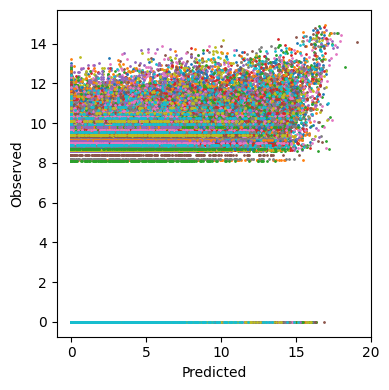

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for idx in np.random.choice(np.arange(pred_res.shape[0]), size=min(100, pred_res.shape[0]), replace=False):
    ax.scatter(pred_res[idx, ], expr[idx, ], s=1)
ax.set_xlabel('Predicted')
ax.set_ylabel('Observed')
plt.tight_layout()
plt.show()

## 6. t-SNE of the Embedding

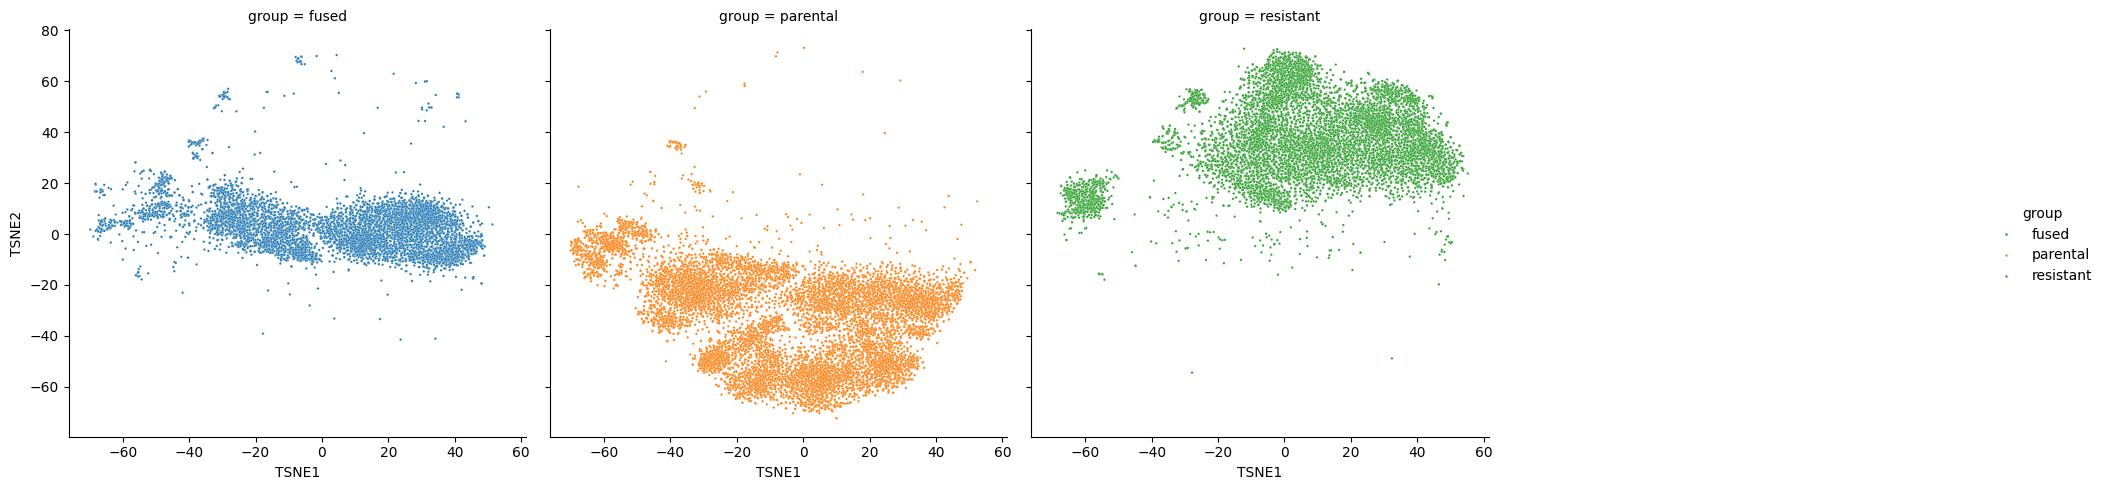

In [29]:
tsne_res = TSNE(n_components=2, n_jobs=-1).fit_transform(emb_res)
df_tsne = pd.DataFrame({
    'group': adata_embed_input.obs['sample'].values,
    'TSNE1': tsne_res[:, 0],
    'TSNE2': tsne_res[:, 1],
})

sns.relplot(df_tsne, x='TSNE1', y='TSNE2', hue='group', kind='scatter', s=3, col='group', col_wrap=4)
plt.savefig('tsne_res_sc_embedding.png')
plt.show()

## 6b. Map In-House Cells onto the Reference (`lung_ext`) Embedding Space

The t-SNE above only shows your in-house cells relative to each other. To see whether/where they
overlap with the broader population `sc_embedd` was trained on, embed the reference cohort too and
plot both in one shared t-SNE (embedding new + reference points together, rather than projecting
onto a fixed space, since plain t-SNE has no `.transform()` for out-of-sample points).

Needs the original `lung_ext_obs.tsv.gz` / `lung_ext_mat.npy` files (likely sitting next to the
`lung_ext_feat.tsv.gz` you already found for `MODEL_FEAT_PATH`). Set the paths below once located.

**Caveat**: the reference cohort gets embedded using its *own real* per-cell batch labels (from
`ref_obs['batch']`), while your in-house cells still use the `REFERENCE_BATCH_INDEX` stopgap from
Section 3 — check Section 4's sensitivity result before reading too much into exact positions of
in-house cells relative to reference clusters; the source-level separation is more trustworthy than
fine-grained placement if the embedding turned out to be batch-sensitive.

If `ref_obs['batch']` turns out to have exactly 19 unique values, that's also your answer for the
real training batch categories — worth feeding back into `BATCH_OBS_PATH` in Section 3.

In [ ]:
REF_OBS_PATH = None   # e.g. f'{wd}/lung_ext_obs.tsv.gz'
REF_MAT_PATH = None   # e.g. f'{wd}/lung_ext_mat.npy'

if REF_OBS_PATH is not None and REF_MAT_PATH is not None:
    ref_obs = pd.read_csv(REF_OBS_PATH, sep='\t')
    ref_expr = np.load(REF_MAT_PATH).astype(np.float32)
    assert ref_expr.shape[0] == ref_obs.shape[0], (
        f'{ref_expr.shape[0]} cells in {REF_MAT_PATH} vs {ref_obs.shape[0]} rows in '
        f'{REF_OBS_PATH} -- these files are not a matched pair.'
    )
    assert ref_expr.shape[1] == expr.shape[1], (
        f'Reference feature width {ref_expr.shape[1]} != in-house feature width {expr.shape[1]} '
        '-- reference matrix is not on the same gene panel as MODEL_FEAT_PATH.'
    )

    ref_uniq_s = sorted(list(ref_obs['batch'].drop_duplicates()))
    ref_uniq_m = dict(zip(ref_uniq_s, np.arange(len(ref_uniq_s))))
    ref_x_batch = np.vstack([
        np.eye(len(ref_uniq_s), dtype=np.float32)[ref_uniq_m[s], ] for s in ref_obs['batch']
    ])
    print(f'Reference batch categories ({len(ref_uniq_s)}): {ref_uniq_s}')
    assert ref_x_batch.shape[1] == BATCH_WIDTH, (
        f'Reference batch width {ref_x_batch.shape[1]} != model-expected {BATCH_WIDTH} -- '
        'this obs file is probably not the actual training cohort.'
    )

    ref_ds = tf.data.Dataset.from_tensor_slices((ref_expr, ref_x_batch)).batch(32)
    ref_emb_res = []
    for step, local_batch in enumerate(ref_ds):
        print(f'\rEmbedding reference step {step}', end='')
        out = call_fn(local_batch[0], local_batch[1])
        if isinstance(out, dict):
            out = list(out.values())
        ref_emb_res.append(out[0].numpy())
    ref_emb_res = np.vstack(ref_emb_res)
    print(f'\nReference embedding shape: {ref_emb_res.shape}')
else:
    ref_emb_res = None
    print('REF_OBS_PATH / REF_MAT_PATH not set -- skipping reference embedding. Look for '
          'lung_ext_obs.tsv.gz and lung_ext_mat.npy alongside the feat file used for '
          'MODEL_FEAT_PATH.')

In [ ]:
if ref_emb_res is not None:
    ref_group = (
        list(ref_obs['cell_type']) if 'cell_type' in ref_obs.columns
        else ['reference'] * ref_emb_res.shape[0]
    )
    joint_emb = np.vstack([ref_emb_res, emb_res])
    joint_source = (['reference (lung_ext)'] * ref_emb_res.shape[0]
                     + ['in-house'] * emb_res.shape[0])
    joint_group = ref_group + list(adata_embed_input.obs['sample'].values)

    joint_tsne = TSNE(n_components=2, n_jobs=-1, random_state=42).fit_transform(joint_emb)
    df_joint = pd.DataFrame({
        'source': joint_source,
        'group': joint_group,
        'TSNE1': joint_tsne[:, 0],
        'TSNE2': joint_tsne[:, 1],
    })

    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    for src, sub in df_joint.groupby('source'):
        ax.scatter(sub['TSNE1'], sub['TSNE2'], s=3, alpha=0.5, label=src)
    ax.set_xlabel('TSNE1')
    ax.set_ylabel('TSNE2')
    ax.set_title('In-House Cells Mapped onto Reference Embedding Space')
    ax.legend(markerscale=4)
    plt.tight_layout()
    plt.savefig('tsne_inhouse_vs_reference.png')
    plt.show()
else:
    print('Skipping joint plot -- set REF_OBS_PATH / REF_MAT_PATH in the previous cell first.')

In [ ]:
if ref_emb_res is not None:
    sns.relplot(
        df_joint[df_joint['source'] == 'in-house'],
        x='TSNE1', y='TSNE2', hue='group', kind='scatter', s=4,
    )
    plt.suptitle('In-House Cells (same coordinate space as above), by Sample', y=1.02)
    plt.show()

    # Reference cell types as biological context (if the obs file carries them), with in-house
    # cells overlaid on top -- shows which reference cell-type neighborhoods your data lands near.
    if 'cell_type' in ref_obs.columns:
        fig, ax = plt.subplots(1, 1, figsize=(8, 7))
        ref_mask = df_joint['source'] == 'reference (lung_ext)'
        for ct, sub in df_joint[ref_mask].groupby('group'):
            ax.scatter(sub['TSNE1'], sub['TSNE2'], s=2, alpha=0.35, label=ct)
        inhouse_mask = df_joint['source'] == 'in-house'
        ax.scatter(df_joint.loc[inhouse_mask, 'TSNE1'], df_joint.loc[inhouse_mask, 'TSNE2'],
                   s=6, color='black', alpha=0.8, label='in-house (all)')
        ax.set_title('In-House Cells Overlaid on Reference Cell Types')
        ax.legend(fontsize='xx-small', markerscale=3, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig('tsne_inhouse_over_reference_celltypes.png')
        plt.show()
    else:
        print("No 'cell_type' column in ref_obs -- skipping the reference-cell-type overlay plot.")

## 7. Train RF / RF+LDA Classifiers on the Embedding

Same classifier setup as `Fusion_signature_Oct2025.ipynb` (`SelectKBest` → optional LDA → Random
Forest, 10-fold stratified CV), but with `X = emb_res` instead of raw HVG expression. `k_best` is
capped at the embedding's actual dimensionality since `emb_res` is already low-dimensional.

In [30]:
X_emb = emb_res
y_emb = adata_embed_input.obs['sample'].values

X_emb_train, X_emb_test, y_emb_train, y_emb_test = train_test_split(
    X_emb, y_emb, test_size=0.2, random_state=42, stratify=y_emb
)

k_best_emb = min(2000, X_emb.shape[1])
selector_emb = SelectKBest(score_func=f_classif, k=k_best_emb)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

clf_rf_emb = Pipeline([
    ('scaler', StandardScaler()),
    ('select', selector_emb),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
])
clf_rf_emb.fit(X_emb_train, y_emb_train)
scores_rf_emb = cross_val_score(clf_rf_emb, X_emb_train, y_emb_train, cv=cv)
print('Embedding RF - Training Accuracy: %.3f ± %.3f' % (scores_rf_emb.mean(), scores_rf_emb.std()))

lda_emb = LinearDiscriminantAnalysis()
clf_rf_lda_emb = Pipeline([
    ('scaler', StandardScaler()),
    ('select', selector_emb),
    ('lda', lda_emb),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
])
clf_rf_lda_emb.fit(X_emb_train, y_emb_train)
scores_rf_lda_emb = cross_val_score(clf_rf_lda_emb, X_emb_train, y_emb_train, cv=cv)
print('Embedding RF+LDA - Training Accuracy: %.3f ± %.3f' % (scores_rf_lda_emb.mean(), scores_rf_lda_emb.std()))

joblib.dump(clf_rf_emb, 'rf_embedding_classifier_model.pkl')
joblib.dump(clf_rf_lda_emb, 'rf_lda_embedding_classifier_model.pkl')

Embedding RF - Training Accuracy: 0.954 ± 0.004
Embedding RF+LDA - Training Accuracy: 0.992 ± 0.002


['rf_lda_embedding_classifier_model.pkl']

In [31]:
y_pred_rf_emb = clf_rf_emb.predict(X_emb_test)
y_pred_rf_lda_emb = clf_rf_lda_emb.predict(X_emb_test)

print('Embedding RF Test Accuracy:', accuracy_score(y_emb_test, y_pred_rf_emb))
print('Embedding RF Classification Report:\n', classification_report(y_emb_test, y_pred_rf_emb))

print('Embedding RF+LDA Test Accuracy:', accuracy_score(y_emb_test, y_pred_rf_lda_emb))
print('Embedding RF+LDA Classification Report:\n', classification_report(y_emb_test, y_pred_rf_lda_emb))

le_emb = LabelEncoder()
y_emb_test_encoded = le_emb.fit_transform(y_emb_test)
y_pred_rf_emb_enc = le_emb.transform(y_pred_rf_emb)
y_pred_rf_lda_emb_enc = le_emb.transform(y_pred_rf_lda_emb)

report_df_rf_emb = pd.DataFrame(
    classification_report(y_emb_test, y_pred_rf_emb, output_dict=True)
).transpose().round(3)
report_df_rf_lda_emb = pd.DataFrame(
    classification_report(y_emb_test, y_pred_rf_lda_emb, output_dict=True)
).transpose().round(3)

Embedding RF Test Accuracy: 0.9533154306961371
Embedding RF Classification Report:
               precision    recall  f1-score   support

       fused       0.99      0.85      0.91      1161
    parental       0.94      0.99      0.97      2009
   resistant       0.95      0.98      0.96      1671

    accuracy                           0.95      4841
   macro avg       0.96      0.94      0.95      4841
weighted avg       0.95      0.95      0.95      4841

Embedding RF+LDA Test Accuracy: 0.9909109688080975
Embedding RF+LDA Classification Report:
               precision    recall  f1-score   support

       fused       0.98      0.99      0.98      1161
    parental       1.00      1.00      1.00      2009
   resistant       0.99      0.99      0.99      1671

    accuracy                           0.99      4841
   macro avg       0.99      0.99      0.99      4841
weighted avg       0.99      0.99      0.99      4841



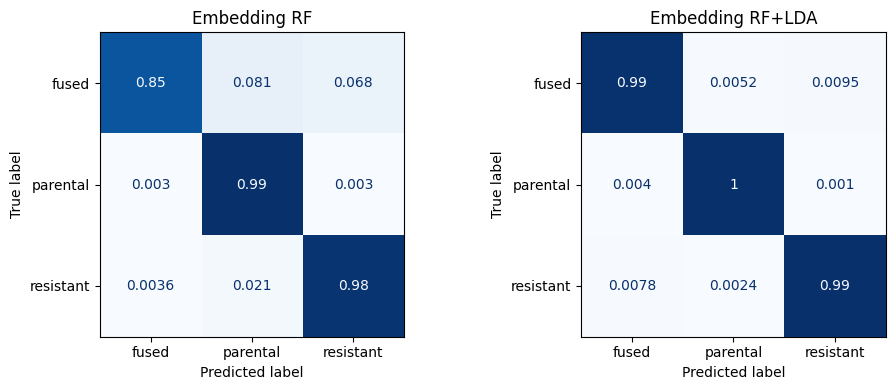

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_rf_emb = confusion_matrix(y_emb_test_encoded, y_pred_rf_emb_enc, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_rf_emb, display_labels=le_emb.classes_).plot(
    ax=axes[0], cmap=plt.cm.Blues, colorbar=False
)
axes[0].set_title('Embedding RF')

cm_rf_lda_emb = confusion_matrix(y_emb_test_encoded, y_pred_rf_lda_emb_enc, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_rf_lda_emb, display_labels=le_emb.classes_).plot(
    ax=axes[1], cmap=plt.cm.Blues, colorbar=False
)
axes[1].set_title('Embedding RF+LDA')

plt.tight_layout()
plt.savefig('embedding_confusion_matrices.png')
plt.show()

## 8. Reproduce the Original HVG-Expression Classifiers

Re-run the original RF / RF+LDA classifiers from `Fusion_signature_Oct2025.ipynb` on `adata_combined_filtered`,
which is now built independently of the embedding branch using the exact original preprocessing
(`normalize_total(target_sum=1e6)` + plain `log1p`, no `exclude_highly_expressed`) — see Section 1.
Identical `random_state`/split/hyperparameter logic to the original notebook, so results should
match up to environment/version differences, and this stays true even as embedding-branch
preprocessing changes independently.

In [ ]:
X_hvg = adata_combined_filtered.X
if hasattr(X_hvg, 'toarray'):
    X_hvg = X_hvg.toarray()
y_hvg = adata_combined_filtered.obs['sample'].values

X_hvg_train, X_hvg_test, y_hvg_train, y_hvg_test = train_test_split(
    X_hvg, y_hvg, test_size=0.2, random_state=42, stratify=y_hvg
)

selector_hvg = SelectKBest(score_func=f_classif, k=min(2000, X_hvg.shape[1]))

clf_rf_hvg = Pipeline([
    ('scaler', StandardScaler()),
    ('select', selector_hvg),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
])
clf_rf_hvg.fit(X_hvg_train, y_hvg_train)
scores_rf_hvg = cross_val_score(clf_rf_hvg, X_hvg_train, y_hvg_train, cv=cv)
print('HVG RF - Training Accuracy: %.3f ± %.3f' % (scores_rf_hvg.mean(), scores_rf_hvg.std()))

lda_hvg = LinearDiscriminantAnalysis()
clf_rf_lda_hvg = Pipeline([
    ('scaler', StandardScaler()),
    ('select', selector_hvg),
    ('lda', lda_hvg),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
])
clf_rf_lda_hvg.fit(X_hvg_train, y_hvg_train)
scores_rf_lda_hvg = cross_val_score(clf_rf_lda_hvg, X_hvg_train, y_hvg_train, cv=cv)
print('HVG RF+LDA - Training Accuracy: %.3f ± %.3f' % (scores_rf_lda_hvg.mean(), scores_rf_lda_hvg.std()))

y_pred_rf_hvg = clf_rf_hvg.predict(X_hvg_test)
y_pred_rf_lda_hvg = clf_rf_lda_hvg.predict(X_hvg_test)

print('HVG RF Test Accuracy:', accuracy_score(y_hvg_test, y_pred_rf_hvg))
print('HVG RF+LDA Test Accuracy:', accuracy_score(y_hvg_test, y_pred_rf_lda_hvg))

## 9. Compare Embedding-Based vs. HVG-Expression-Based Classifiers

Side-by-side CV accuracy (boxplot) and test-set metrics for all four models: RF and RF+LDA, each
trained on either the `sc_embedd` embedding or raw HVG expression.

In [ ]:
dict_res = {
    'HVG RF': scores_rf_hvg,
    'HVG RF+LDA': scores_rf_lda_hvg,
    'Embedding RF': scores_rf_emb,
    'Embedding RF+LDA': scores_rf_lda_emb,
}
categories = list(dict_res.keys())
values = list(dict_res.values())

plt.figure(figsize=(8, 6))
plt.boxplot(values, patch_artist=True, tick_labels=categories)
plt.ylabel('CV Accuracy')
plt.title('Embedding- vs. HVG-Expression-Based Classifiers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('embedding_vs_hvg_cv_accuracy.png')
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'model': categories,
    'cv_accuracy_mean': [v.mean() for v in values],
    'cv_accuracy_std': [v.std() for v in values],
    'test_accuracy': [
        accuracy_score(y_hvg_test, y_pred_rf_hvg),
        accuracy_score(y_hvg_test, y_pred_rf_lda_hvg),
        accuracy_score(y_emb_test, y_pred_rf_emb),
        accuracy_score(y_emb_test, y_pred_rf_lda_emb),
    ],
})
comparison_df

## 10. ROC Curves — Embedding-Based Classifiers

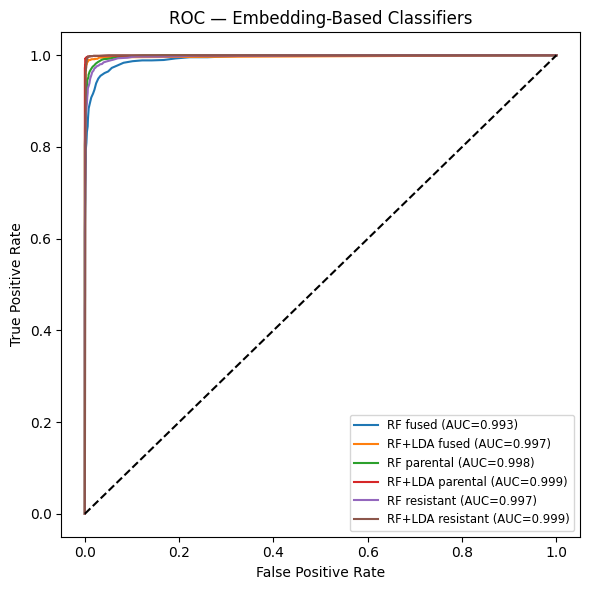

In [36]:
y_score_rf_emb = clf_rf_emb.predict_proba(X_emb_test)
y_score_rf_lda_emb = clf_rf_lda_emb.predict_proba(X_emb_test)

classes_emb = np.unique(y_emb_test)
y_bin_emb = label_binarize(y_emb_test, classes=classes_emb)

plt.figure(figsize=(6, 6))
for i, class_name in enumerate(classes_emb):
    fpr_rf, tpr_rf, _ = roc_curve(y_bin_emb[:, i], y_score_rf_emb[:, i])
    auc_rf = roc_auc_score(y_bin_emb[:, i], y_score_rf_emb[:, i])

    fpr_lda, tpr_lda, _ = roc_curve(y_bin_emb[:, i], y_score_rf_lda_emb[:, i])
    auc_lda = roc_auc_score(y_bin_emb[:, i], y_score_rf_lda_emb[:, i])

    plt.plot(fpr_rf, tpr_rf, label=f'RF {class_name} (AUC={auc_rf:.3f})')
    plt.plot(fpr_lda, tpr_lda, label=f'RF+LDA {class_name} (AUC={auc_lda:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC — Embedding-Based Classifiers')
plt.legend(fontsize='small')
plt.tight_layout()
plt.savefig('ROC_embedding.png')
plt.show()